# 07_mobility_analysis.ipynb
## Project Title: Traffic Accident Risk Prediction (TARP)
**Unit:** SIT782  
**Prepared by:** Subathira Thinakaran  

**Project Team:**  
- Suba (225094537)  
- Burhan (224802775)  
- Khalid (224696667)  

**Task:** Exploratory Data Analysis – Mobility Data (Week 3 of 8)

## Objective
This notebook performs exploratory data analysis on the cleaned pedestrian and bicycle datasets prepared in the previous stage of the TARP project.

The aim is to identify mobility patterns that may support later feature engineering and accident risk prediction, with a focus on:
- pedestrian activity by hour
- bicycle traffic by hour
- bicycle traffic by day
- bicycle traffic by weekday
- comparison of mobility patterns

## Datasets Used
/data/processed/pedestrian_clean.csv
/data/processed/bicycle_clean.csv
/data/processed/bicycle_hourly.csv
/data/processed/bicycle_daily.csv
/data/processed/bicycle_weekday.csv


## Output
- Pedestrian activity by hour (line chart)
- Bicycle traffic by hour (line chart)
- Bicycle traffic by day (time-series chart)
- Bicycle traffic by weekday (line chart)
- Comparison of pedestrian and bicycle activity by hour (dual-axis chart)

In [1]:
# -----------------------------
# 1. Import libraries
# -----------------------------
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving bicycle_weekday.csv to bicycle_weekday.csv
Saving bicycle_daily.csv to bicycle_daily.csv
Saving bicycle_hourly.csv to bicycle_hourly.csv
Saving bicycle_clean.csv to bicycle_clean.csv
Saving pedestrian_clean.csv to pedestrian_clean.csv


## Load Cleaned Datasets

This section loads the cleaned pedestrian and bicycle datasets generated in the previous notebook.

In [4]:
# -----------------------------
# 2. Load processed datasets
# -----------------------------
PROCESSED_DATA_DIR = Path("data/processed")

pedestrian_file = PROCESSED_DATA_DIR / "pedestrian_clean.csv"
bicycle_clean_file = PROCESSED_DATA_DIR / "bicycle_clean.csv"
bicycle_hourly_file = PROCESSED_DATA_DIR / "bicycle_hourly.csv"
bicycle_daily_file = PROCESSED_DATA_DIR / "bicycle_daily.csv"
bicycle_weekday_file = PROCESSED_DATA_DIR / "bicycle_weekday.csv"

# Fallback for Colab/manual upload
if not pedestrian_file.exists():
    print("Using uploaded files in current directory...")
    pedestrian_file = Path("pedestrian_clean.csv")
    bicycle_clean_file = Path("bicycle_clean.csv")
    bicycle_hourly_file = Path("bicycle_hourly.csv")
    bicycle_daily_file = Path("bicycle_daily.csv")
    bicycle_weekday_file = Path("bicycle_weekday.csv")

# Load datasets
pedestrian_df = pd.read_csv(pedestrian_file)
bicycle_clean_df = pd.read_csv(bicycle_clean_file)
bicycle_hourly = pd.read_csv(bicycle_hourly_file)
bicycle_daily = pd.read_csv(bicycle_daily_file)
bicycle_weekday = pd.read_csv(bicycle_weekday_file)

# Print summary
print("Dataset Summary:")
print(f"Pedestrian dataset: {pedestrian_df.shape}")
print(f"Bicycle clean dataset: {bicycle_clean_df.shape}")
print(f"Bicycle hourly dataset: {bicycle_hourly.shape}")
print(f"Bicycle daily dataset: {bicycle_daily.shape}")
print(f"Bicycle weekday dataset: {bicycle_weekday.shape}")

Using uploaded files in current directory...
Dataset Summary:
Pedestrian dataset: (5000, 11)
Bicycle clean dataset: (3109, 15)
Bicycle hourly dataset: (24, 2)
Bicycle daily dataset: (249, 2)
Bicycle weekday dataset: (7, 2)


### Observation

All processed datasets were successfully loaded. The pedestrian dataset contains 5000 cleaned records, while the bicycle dataset contains 3109 valid records after filtering missing values.

The aggregated bicycle datasets provide hourly, daily, and weekday-level summaries, which will support detailed exploratory analysis in the following sections.

## Initial Inspection

Inspect the structure of the processed datasets before analysis.

In [6]:
# -----------------------------
# 3. Initial inspection
# -----------------------------
print("Pedestrian columns:")
print(list(pedestrian_df.columns))

print("\nBicycle clean columns:")
print(list(bicycle_clean_df.columns))

print("\nPedestrian preview:")
display(pedestrian_df.head())

print("\nBicycle preview:")
display(bicycle_clean_df.head())

# Quick validation checks
print("\nUnique pedestrian sensors:", pedestrian_df["sensor_name"].nunique())
print("Unique bicycle roads:", bicycle_clean_df["road_name"].nunique())

Pedestrian columns:
['id', 'location_id', 'sensor_name', 'sensing_date', 'hourday', 'timestamp', 'direction_1', 'direction_2', 'pedestriancount', 'latitude', 'longitude']

Bicycle clean columns:
['date', 'day_of_week', 'is_weekend', 'time', 'hour', 'road_name', 'location', 'suburb', 'direction', 'speed_limit', 'bike', 'average_speed', '85th_percentile_speed', 'maximum_speed', 'road_segment']

Pedestrian preview:


,id,location_id,sensor_name,sensing_date,hourday,timestamp,direction_1,direction_2,pedestriancount,latitude,longitude
0,135920240721,135,Spen161_T,2024-07-21,9,2024-07-21 09:00:00,226,225,451,-37.817286,144.953191
1,135220250609,135,Spen161_T,2025-06-09,2,2025-06-09 02:00:00,9,21,30,-37.817286,144.953191
2,132520250803,132,King335_T,2025-08-03,5,2025-08-03 05:00:00,8,4,12,-37.812676,144.953864
3,1342020240829,134,Spen201_T,2024-08-29,20,2024-08-29 20:00:00,311,233,544,-37.816942,144.953039
4,1342020260104,134,Spen201_T,2026-01-04,20,2026-01-04 20:00:00,264,253,517,-37.816942,144.953039



Bicycle preview:


,date,day_of_week,is_weekend,time,hour,road_name,location,suburb,direction,speed_limit,bike,average_speed,85th_percentile_speed,maximum_speed,road_segment
0,2015-04-24,Friday,False,6:00,6,Rosslyn Street,Between Adderley Street and Spencer Street,West Melbourne,E,50,1.0,26.0,29.0,35.0,21479
1,2015-04-24,Friday,False,16:00,16,Rosslyn Street,Between Adderley Street and Spencer Street,West Melbourne,E,50,0.0,31.0,39.0,51.0,21479
2,2015-04-24,Friday,False,19:00,19,Rosslyn Street,Between Adderley Street and Spencer Street,West Melbourne,E,50,1.0,32.0,36.0,43.0,21479
3,2015-04-25,Saturday,True,15:00,15,Rosslyn Street,Between Adderley Street and Spencer Street,West Melbourne,E,50,0.0,20.0,23.0,25.0,21479
4,2015-04-25,Saturday,True,18:00,18,Rosslyn Street,Between Adderley Street and Spencer Street,West Melbourne,E,50,0.0,44.0,48.0,64.0,21479



Unique pedestrian sensors: 98
Unique bicycle roads: 62


### Observation

The pedestrian dataset contains timestamped mobility records along with spatial coordinates, making it suitable for temporal and spatial analysis.

The bicycle dataset includes date, time, and derived temporal features such as hour, day of week, and weekend indicators, along with clean bicycle count values. This confirms that both datasets are well-prepared for exploratory analysis of mobility patterns.

## Analysis of Pedestrian Activity by Hour

This section aggregates pedestrian counts by hour to understand how pedestrian movement varies throughout the day.

In [ ]:
# -----------------------------
# 4. Prepare pedestrian hourly data
# -----------------------------
pedestrian_df["timestamp"] = pd.to_datetime(pedestrian_df["timestamp"], errors="coerce")
pedestrian_df["hour"] = pedestrian_df["timestamp"].dt.hour

ped_hourly = (
    pedestrian_df
    .groupby("hour", as_index=False)["pedestriancount"]
    .sum()
    .sort_values("hour")
    .reset_index(drop=True)
)

print("Pedestrian hourly shape:", ped_hourly.shape)
print("Hour range:", ped_hourly["hour"].min(), "-", ped_hourly["hour"].max())

ped_hourly.head()

Pedestrian hourly shape: (24, 2)


,hour,pedestriancount
0,0,16070
1,1,13952
2,2,5057
3,3,2567
4,4,3353


### Observation

Pedestrian activity is recorded across all 24 hours of the day. Lower activity is observed during early morning hours, while higher counts appear during daytime and evening periods.

These patterns reflect typical urban mobility behaviour and indicate periods of increased pedestrian density, which may correspond to higher exposure to traffic interactions.

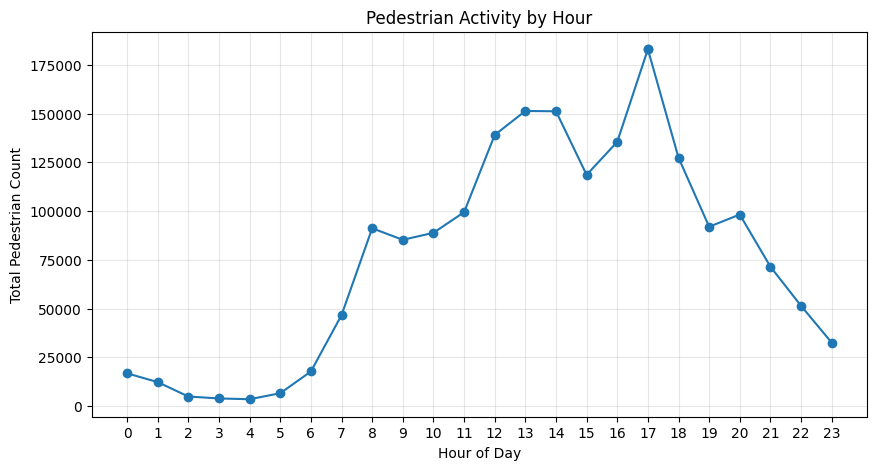

In [10]:
# -----------------------------
# 5. Plot pedestrian activity by hour
# -----------------------------
# Ensure ped_hourly exists
if "ped_hourly" not in globals():
    pedestrian_df["timestamp"] = pd.to_datetime(pedestrian_df["timestamp"], errors="coerce")
    pedestrian_df["hour"] = pedestrian_df["timestamp"].dt.hour

    ped_hourly = (
        pedestrian_df
        .groupby("hour", as_index=False)["pedestriancount"]
        .sum()
        .sort_values("hour")
        .reset_index(drop=True)
    )

plt.figure(figsize=(10, 5))
plt.plot(ped_hourly["hour"], ped_hourly["pedestriancount"], marker="o")

# Highlight peak
peak_hour = ped_hourly.loc[ped_hourly["pedestriancount"].idxmax(), "hour"]
peak_value = ped_hourly["pedestriancount"].max()
plt.scatter(peak_hour, peak_value)

plt.xlabel("Hour of Day")
plt.ylabel("Total Pedestrian Count")
plt.title("Pedestrian Activity by Hour")

plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

plt.show()

### Observation

The pedestrian activity pattern shows very low movement during early morning hours (2 AM to 5 AM), followed by a sharp increase beginning around 7 AM, indicating the start of daily commuting.

Activity remains high during midday and reaches its peak at approximately 5 PM, suggesting strong evening movement likely associated with post-work commuting and urban activity.

After this peak, pedestrian counts gradually decline into the night. These patterns highlight specific high-density periods that may correspond to increased exposure to traffic and potential accident risk.

## Analysis of Bicycle Traffic by Hour

This section analyses how bicycle traffic varies across different hours of the day.

In [11]:
# -----------------------------
# 6. Create bicycle hourly summary
# -----------------------------
bicycle_hourly = (
    bicycle_clean_df
    .groupby("hour", as_index=False)["bike"]
    .sum()
    .sort_values("hour")
    .reset_index(drop=True)
)

print("Bicycle hourly shape:", bicycle_hourly.shape)
print("Hour range:", bicycle_hourly["hour"].min(), "-", bicycle_hourly["hour"].max())

bicycle_hourly.head()

Bicycle hourly shape: (24, 2)
Hour range: 0 - 23


,hour,bike
0,0,47.0
1,1,57.0
2,2,22.0
3,3,47.0
4,4,37.0


### Observation

The bicycle hourly summary is generated directly from the cleaned dataset to ensure accuracy. This provides a complete view of bicycle traffic across all hours of the day, enabling meaningful comparison with pedestrian activity.

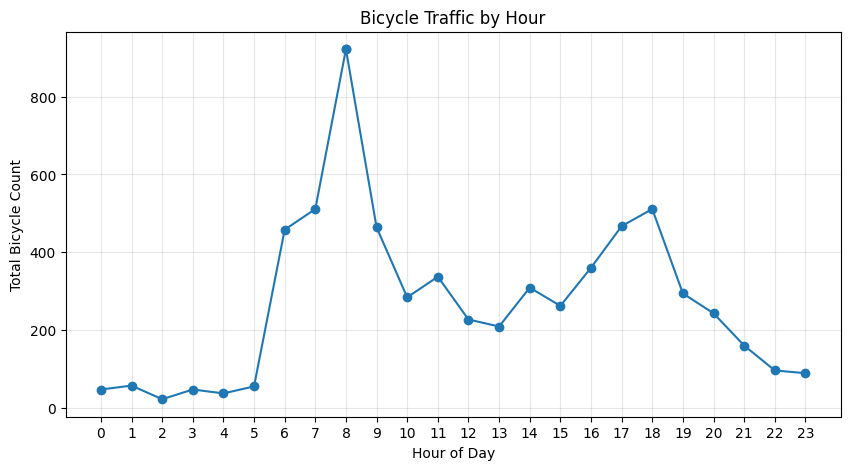

In [13]:
# -----------------------------
# 7. Plot bicycle traffic by hour
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(bicycle_hourly["hour"], bicycle_hourly["bike"], marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Total Bicycle Count")
plt.title("Bicycle Traffic by Hour")

plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

peak_hour = bicycle_hourly.loc[bicycle_hourly["bike"].idxmax(), "hour"]
peak_value = bicycle_hourly["bike"].max()

plt.scatter(peak_hour, peak_value)

plt.show()

### Observation

Bicycle traffic is low during early morning hours and increases sharply in the morning, reaching a clear peak around 8 AM, which is highlighted in the chart. This indicates strong morning commuting behaviour among cyclists.

Following this peak, bicycle activity decreases but remains moderate throughout the day. A secondary increase is observed in the late afternoon and early evening, suggesting return commuting patterns.

Overall, bicycle traffic is more concentrated around specific commuting hours compared to pedestrian activity, highlighting distinct mobility behaviours between transport modes.

## Analysis of Bicycle Traffic by Day

This section analyses how bicycle traffic varies across different dates to identify temporal trends and fluctuations over time.

In [15]:
# -----------------------------
# 8. Review bicycle daily summary
# -----------------------------
bicycle_daily["date"] = pd.to_datetime(bicycle_daily["date"], errors="coerce")
bicycle_daily = bicycle_daily.sort_values("date").reset_index(drop=True)

print("Bicycle daily shape:", bicycle_daily.shape)
print("Date range:", bicycle_daily["date"].min(), "to", bicycle_daily["date"].max())

print("\nMissing values:", bicycle_daily.isna().sum().to_dict())

bicycle_daily.head()

Bicycle daily shape: (249, 2)
Date range: 2015-01-03 00:00:00 to 2017-10-02 00:00:00

Missing values: {'date': 0, 'bike': 0}


,date,bike
0,2015-01-03,9.0
1,2015-01-06,6.0
2,2015-01-09,90.0
3,2015-01-12,32.0
4,2015-02-03,17.0


### Observation

The bicycle dataset spans 249 unique dates between 2015 and 2017, providing a strong temporal range for analysis. The variation in daily bicycle counts indicates that traffic levels fluctuate over time rather than remaining constant.

This day-level perspective enables identification of trends, irregular patterns, and potential external influences on bicycle activity, which are important for understanding mobility behaviour in the context of accident risk.

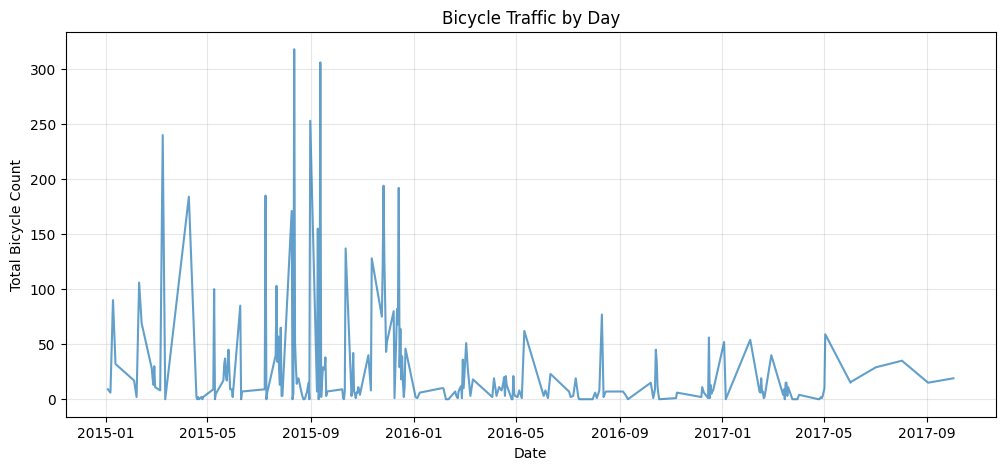

In [18]:
# -----------------------------
# 9. Plot bicycle traffic by day
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(bicycle_daily["date"], bicycle_daily["bike"], alpha=0.7)

plt.xlabel("Date")
plt.ylabel("Total Bicycle Count")
plt.title("Bicycle Traffic by Day")

plt.grid(True, alpha=0.3)
plt.show()

### Observation

The bicycle daily trend shows significant variability over time, with irregular spikes and fluctuations rather than a smooth continuous pattern. Notably, higher peaks are observed in earlier periods (around 2015), while later periods show generally lower and more stable values.

This irregular pattern suggests that the dataset may represent sampled or location-specific measurements rather than continuous daily traffic counts. As a result, bicycle activity appears uneven across dates, with some days recording significantly higher traffic than others.

These variations highlight the importance of considering data collection patterns when interpreting mobility trends, and they provide useful insight into how bicycle traffic may fluctuate under different conditions.

## Analysis of Bicycle Traffic by Weekday

This section compares bicycle activity across days of the week.

In [21]:
# -----------------------------
# 10. Review bicycle weekday summary
# -----------------------------
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

bicycle_weekday["day_of_week"] = pd.Categorical(
    bicycle_weekday["day_of_week"],
    categories=weekday_order,
    ordered=True
)

bicycle_weekday = bicycle_weekday.sort_values("day_of_week").reset_index(drop=True)

print("Bicycle weekday shape:", bicycle_weekday.shape)
print("\nWeekday coverage:", list(bicycle_weekday["day_of_week"]))

bicycle_weekday

Bicycle weekday shape: (7, 2)

Weekday coverage: ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


,day_of_week,bike
0,Monday,1261.0
1,Tuesday,707.0
2,Wednesday,1094.0
3,Thursday,1195.0
4,Friday,772.0
5,Saturday,895.0
6,Sunday,544.0


### Observation

The weekday analysis shows that bicycle traffic is highest at the beginning and middle of the workweek, with Monday recording the highest activity, followed by Thursday and Wednesday.

Traffic levels decrease towards the weekend, with Sunday showing the lowest bicycle activity. This pattern suggests that cycling behaviour is strongly influenced by weekday commuting routines, with reduced activity during non-working days.

These insights highlight the role of regular work schedules in shaping bicycle mobility patterns, which may be important when analysing accident risk across different days.

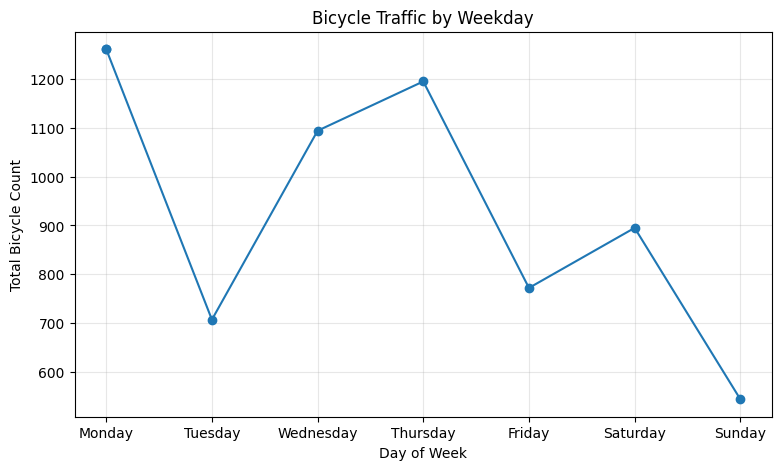

In [23]:
# -----------------------------
# 11. Plot bicycle traffic by weekday
# -----------------------------
plt.figure(figsize=(9, 5))
plt.plot(bicycle_weekday["day_of_week"], bicycle_weekday["bike"], marker="o")

peak_day = bicycle_weekday.loc[bicycle_weekday["bike"].idxmax(), "day_of_week"]
peak_value = bicycle_weekday["bike"].max()

plt.scatter(peak_day, peak_value)

plt.xlabel("Day of Week")
plt.ylabel("Total Bicycle Count")
plt.title("Bicycle Traffic by Weekday")

plt.grid(True, alpha=0.3)
plt.show()

### Observation

The weekday plot clearly shows that bicycle traffic is highest on Monday and remains relatively high during mid-week, particularly on Wednesday and Thursday. This indicates strong commuting behaviour at the start and middle of the workweek.

Bicycle activity declines towards the weekend, with a noticeable drop on Friday and lower activity on Saturday. Sunday records the lowest traffic, suggesting minimal commuting and reduced cycling activity.

Overall, the pattern highlights that bicycle usage is closely linked to weekday routines, with reduced activity during non-working days.

## Compare Pedestrian and Bicycle Activity by Hour

This section compares pedestrian and bicycle traffic patterns to understand broader mobility behaviour in the project context.

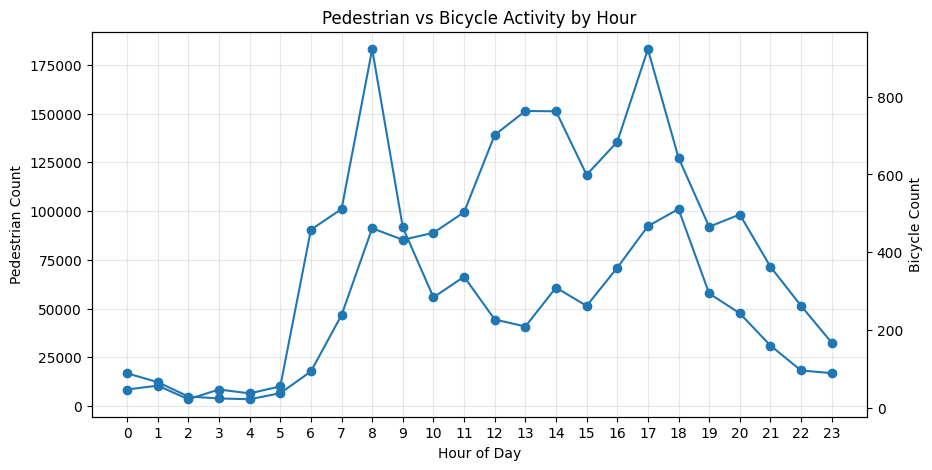

In [25]:
# -----------------------------
# 12. Compare pedestrian and bicycle activity by hour
# -----------------------------
fig, ax1 = plt.subplots(figsize=(10, 5))

# Pedestrian (left axis)
ax1.plot(ped_hourly["hour"], ped_hourly["pedestriancount"], marker="o")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Pedestrian Count")

# Bicycle (right axis)
ax2 = ax1.twinx()
ax2.plot(bicycle_hourly["hour"], bicycle_hourly["bike"], marker="o")
ax2.set_ylabel("Bicycle Count")

plt.title("Pedestrian vs Bicycle Activity by Hour")
plt.xticks(range(0, 24))
ax1.grid(True, alpha=0.3)

plt.show()

### Observation

The dual-axis comparison highlights clear differences in temporal patterns between pedestrian and bicycle activity.

Bicycle traffic exhibits a sharp peak in the morning around 8 AM, indicating strong commuting behaviour. In contrast, pedestrian activity increases more gradually throughout the day and reaches its peak in the late afternoon and early evening, around 5 PM.

Although both modes show increased activity during general commuting hours, their peak times do not fully align. This suggests that pedestrian and bicycle movements contribute differently to urban mobility patterns.

These differences are important for accident risk analysis, as the periods of highest exposure for pedestrians and cyclists occur at different times of the day.

## Final Summary

This notebook performed exploratory data analysis on pedestrian and bicycle mobility datasets obtained from the City of Melbourne Open Data platform.

The analysis revealed distinct temporal patterns for both modes of transport. Pedestrian activity showed a gradual increase throughout the day, peaking in the late afternoon and evening, which aligns with typical urban movement and post-work activity. In contrast, bicycle traffic exhibited a sharp peak in the morning around 8 AM, indicating strong commuting behaviour, followed by a smaller secondary increase in the evening.

Daily bicycle analysis highlighted irregular fluctuations, suggesting that the dataset represents sampled or location-specific measurements rather than continuous daily recordings. Weekday analysis further showed that bicycle usage is higher during working days and decreases on weekends, reinforcing the influence of commuting patterns.

The comparison between pedestrian and bicycle activity demonstrated that peak movement periods do not fully overlap, indicating that different transport modes contribute differently to urban mobility patterns.

Overall, these insights provide a strong foundation for the next stage of the project, where feature engineering and integration of multiple datasets will be used to support accident risk prediction.